# PFC Boost Closed-Loop em Modo Chaveado (Switched-Mode)

Este notebook fecha a malha de controle do estágio **boost PFC** usando
**simulação chaveada** (não modelo médio). Cobre:

```
   220 V_rms AC  →  bridge  →  Lpfc  →  Q_pfc + D_pfc  →  Cdc  →  R_load
                                  ↑ PWM (Vpwm) ←── ACMC controller (Python callback)
```

O controlador (Python) roda a cada timestep do simulador chaveado, lê
`V_dc` e `V_ac` do state, calcula nova duty via PI cascateado (inner
current + outer voltage), e escreve via `circuit.set_pwm_duty()`. Isso
é exatamente o pattern do **PSIM/Simulink** para PFC closed-loop.

## Por que modo chaveado (não modelo médio)

| Aspecto | Average model | Switched mode |
|---|---|---|
| **Velocidade** | rápido (sem chaveamento) | lento (1k–100k steps por ciclo) |
| **Realismo** | aproxima dinâmica lenta | captura ringing, dead-time, comutação real |
| **Validação de controlador** | resposta dinâmica nominal | comportamento sob switching ripple, EMI, current saturation, etc. |
| **Stress de componentes** | só values médios | I_pk, V_DS_max, dissipação real |
| **Limitações reais** | invisíveis | aparecem (e.g. saturação do indutor, slew do MOSFET) |

Modelo médio é ideal para **projetar** o controlador (Bode plot, fc, fz).
Switched mode é o que valida que o controle **funciona** quando colocado
no hardware real.

## A correção de kernel que tornou isso possível

Antes do commit recente (`fc3c686` + `ed879af`):
- `Simulator.run_transient(x0)` chamava `update_history(x, true)` que zerava
  `cap.i_prev`, destruindo state entre construções de Simulator
- `run_transient_streaming` tinha `py::call_guard<py::gil_scoped_release>`
  que crasheava ao copiar `py::object` args sem GIL
- Resultado: closed-loop em pattern per-period **divergia** (vout
  colapsava 24V→13V→4V→0V em 500 períodos)

Depois das correções:
- `has_any_dynamic_history()` evita reinicialização indevida em continuações
- GIL handling corrigido permite callbacks Python re-entrarem no kernel
- Nova API `Simulator.run_transient(x0, ckt, callback)` para closed-loop
  num único run, com SimulationOptions custom

Resultado: closed-loop chaveado **funciona** e rastreia referência.

> **Cobertura deste notebook:** projeto + simulação chaveada da malha
> fechada do PFC. Os cálculos analíticos (sizing dos componentes,
> seleção de switches, análise térmica) estão em
> `boost_pfc_vsi_design.ipynb`. Aqui foco é o controle.


In [1]:
from pathlib import Path
import sys

_root = Path.cwd()
_candidate_paths = []
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir():
            _candidate_paths.append(candidate)
    _root = _root.parent

_seen = set()
for candidate in _candidate_paths:
    cstr = str(candidate)
    if cstr in _seen:
        continue
    _seen.add(cstr)
    if cstr not in sys.path:
        sys.path.insert(0, cstr)

import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f"Pulsim version: {ps.__version__}")
print(f"Has Simulator.run_transient(x0, ckt, callback)? "
      f"{'run_transient' in dir(ps.Simulator)}")


Pulsim version: 0.10.0a11
Has Simulator.run_transient(x0, ckt, callback)? True


## 1. Especificações Reduzidas (para sim rápida)

Vamos usar specs **menores** que `boost_pfc_vsi_design.ipynb` (1 kW vs
5 kW, Cdc menor) para reduzir o transient time-to-settle:

| Parâmetro | Valor |
|---|---|
| `V_ac_rms` | 220 V_rms (60 Hz) |
| `V_dc_ref` | 400 V (regulado) |
| `P_out` | 500 W (load reduzido) |
| `R_load` | 320 Ω |
| `L_pfc` | 1 mH |
| `C_dc` | 220 µF |
| `f_sw` | 50 kHz |

O foco é demonstrar o **controle**, não dimensionar para 5 kW de
verdade. Specs reais ficam em `boost_pfc_vsi_design.ipynb`.


In [2]:
# Specs
V_ac_rms = 220.0
V_ac_peak = V_ac_rms * np.sqrt(2)
f_line = 60.0
V_dc_ref = 400.0
P_out = 500.0
R_load = V_dc_ref**2 / P_out
f_sw = 25e3      # 25 kHz — reduzido p/ demo rápido
T_sw = 1.0 / f_sw
L_pfc = 1e-3
C_dc = 470e-6

print(f"V_ac:      {V_ac_rms} V_rms @ {f_line} Hz  (peak {V_ac_peak:.0f} V)")
print(f"V_dc ref:  {V_dc_ref} V")
print(f"P_out:     {P_out} W → R_load = {R_load:.0f} Ω")
print(f"L_pfc:     {L_pfc*1e3:.1f} mH")
print(f"C_dc:      {C_dc*1e6:.0f} µF  (τ = R·C = {R_load*C_dc*1e3:.1f} ms)")
print(f"f_sw:      {f_sw/1e3:.0f} kHz")


V_ac:      220.0 V_rms @ 60.0 Hz  (peak 311 V)
V_dc ref:  400.0 V
P_out:     500.0 W → R_load = 320 Ω
L_pfc:     1.0 mH
C_dc:      470 µF  (τ = R·C = 150.4 ms)
f_sw:      25 kHz


## 2. Construção do Circuito

Topologia: AC source → bridge rectifier → boost (L + Q + D + Cdc) → R_load.
A bridge é built-in (`add_bridge_rectifier`) e os 4 diodos viram nomeados
`BR__D1..D4`. O MOSFET de chaveamento é low-side, com gate a 10V quando
ON, 0V quando OFF.


In [3]:
ckt = ps.Circuit()
gnd = ps.Circuit.ground()
n_ac1 = ckt.add_node('ac1')
n_ac2 = ckt.add_node('ac2')
n_rect = ckt.add_node('rect')   # bridge DC+ output
n_sw   = ckt.add_node('sw')     # boost switch node
n_out  = ckt.add_node('out')    # DC bus
n_ctrl = ckt.add_node('ctrl')   # gate

# AC source
sp = ps.SineParams()
sp.amplitude = V_ac_peak
sp.frequency = f_line
sp.offset = 0.0
sp.phase = 0.0
ckt.add_sine_voltage_source('Vac', n_ac1, n_ac2, sp)
ckt.add_resistor('Rgrnd', n_ac2, gnd, 1e-3)

# Bridge rectifier
dp = ps.RealisticDiodeParams()
dp.V_F0 = 0.85; dp.R_d = 25e-3
dp.g_on = 1.0/dp.R_d; dp.g_off = 1e-9
ckt.add_bridge_rectifier('BR', n_ac1, n_ac2, n_rect, gnd, dp)

# Boost stage
ckt.add_inductor('Lpfc', n_rect, n_sw, L_pfc)
mp = ps.MOSFETParams(); mp.vth = 2.0; mp.kp = 10.0; mp.g_off = 1e-6
ckt.add_mosfet('Qpfc', n_ctrl, n_sw, gnd, mp)
ckt.add_diode('Dpfc', n_sw, n_out, g_on=200.0, g_off=1e-9)
ckt.add_capacitor('Cdc', n_out, gnd, C_dc)
ckt.add_resistor('Rload', n_out, gnd, R_load)

# PWM gate driver (initial duty 0.5, will be overridden by controller)
pp = ps.PWMParams()
pp.v_high = 10.0; pp.v_low = 0.0
pp.frequency = f_sw; pp.duty = 0.5
ckt.add_pwm_voltage_source('Vpwm', n_ctrl, gnd, pp)

print(f"Circuit: {ckt.num_nodes()} nodes, {ckt.num_branches()} branches, "
      f"system size {ckt.system_size()}")


Circuit: 6 nodes, 3 branches, system size 9


## 3. Controlador ACMC — Outer Voltage Loop

Para esta primeira versão demonstrativa usamos só o **outer voltage loop**:
PI sobre `V_dc_ref - V_dc_lpf`, com feedforward `D_ff = 1 - |V_ac|/V_dc`
para acelerar a resposta.

A versão completa de ACMC adiciona um inner current loop (a corrente do
indutor segue um gabarito senoidal proporcional a |V_ac|), que vamos
estruturar como follow-up depois de validar a arquitetura.

### Tuning
- `Kp = 0.001` (V_dc / V → unitless duty)
- `Ki = 0.5` (V_dc·s / V → unitless duty)
- LPF do V_dc com fc=15Hz (rejeita ripple de 120Hz)
- Anti-windup quando duty satura


In [4]:
# Controller state (closure over `state` dict)
state = {
    'integ_v': 0.0,
    'last_t':  0.0,
    'vdc_lpf': 0.0,
    'duty':    0.5,
    'log_t':   [],
    'log_vdc': [],
    'log_vdc_lpf': [],
    'log_vac': [],
    'log_iL':  [],
    'log_duty': [],
}

Kp_v = 0.0003     # outer V loop P gain (suave para evitar excitar RHP zero)
Ki_v = 0.40       # outer V loop I gain
D_min, D_max = 0.05, 0.85
SOFTSTART_TIME = 0.030   # ramp Vref de 0→V_dc_ref nos primeiros 30 ms
# LPF coefficient for V_dc (15 Hz cutoff vs 120 Hz ripple)
# Computed in callback against actual `dt_loop` for variable-dt safety.

# Pre-set initial duty bem baixo (boost OFF essencialmente)
ckt.set_pwm_duty('Vpwm', 0.10)
state['duty'] = 0.10

# Find indices of nodes we want to log explicitly
nd_out = n_out; nd_ac1 = n_ac1; nd_ac2 = n_ac2

def controller(t, sd):
    """Outer voltage PI with feedforward duty.

    Called after every accepted timestep by the kernel. `sd` is a dict
    with `'V(<node_name>)' = value`. We read V_dc, V_ac, run the PI,
    compute new duty, write it back to the PWM source.
    """
    vdc = sd[f'V(out)']
    vac = sd[f'V(ac1)'] - sd[f'V(ac2)']

    dt_loop = max(t - state['last_t'], 1e-12)
    state['last_t'] = t

    # LPF on V_dc (one-pole IIR, fc = 15 Hz)
    alpha = 1.0 - np.exp(-2.0*np.pi*15.0*dt_loop)
    state['vdc_lpf'] = (1.0 - alpha) * state['vdc_lpf'] + alpha * vdc

    # Soft-start: ramp reference de 0→V_dc_ref nos primeiros SOFTSTART_TIME
    vref_eff = V_dc_ref * min(1.0, t / SOFTSTART_TIME)

    # Outer voltage PI
    err = vref_eff - state['vdc_lpf']
    state['integ_v'] += err * dt_loop
    # Anti-windup mais agressivo: clamp integral em range físico razoável
    INTEG_MAX = (D_max - 0.3) / max(Ki_v, 1e-12)   # nunca mais que esse range no I term
    state['integ_v'] = float(np.clip(state['integ_v'], -INTEG_MAX, INTEG_MAX))

    pi_term = Kp_v * err + Ki_v * state['integ_v']

    # Feedforward: d_ff = 1 - |V_ac|/V_dc_ref
    vac_abs = abs(vac) + 1.0
    duty_ff = max(0.0, min(0.95, 1.0 - vac_abs / V_dc_ref))

    new_duty = float(np.clip(duty_ff + pi_term, D_min, D_max))
    state['duty'] = new_duty
    ckt.set_pwm_duty('Vpwm', new_duty)

    # Log (downsample to keep memory reasonable: log every 50th step)
    if len(state['log_t']) == 0 or t - state['log_t'][-1] >= T_sw:
        state['log_t'].append(t)
        state['log_vdc'].append(vdc)
        state['log_vdc_lpf'].append(state['vdc_lpf'])
        state['log_vac'].append(vac)
        state['log_duty'].append(new_duty)

print(f"Controller initialized: Kp={Kp_v}, Ki={Ki_v}, D∈[{D_min}, {D_max}]")


Controller initialized: Kp=0.0003, Ki=0.4, D∈[0.05, 0.85]


## 4. Simulação Closed-Loop

Rodamos 4 ciclos de linha (66.7 ms) → tempo suficiente para o V_dc
chegar próximo do reference e a malha estabilizar contra o ripple de
120 Hz.


In [5]:
import time

n_line_cycles = 9        # 150ms — chega ao SS razoavelmente
T_total = n_line_cycles / f_line
dt = T_sw / 20   # 20 samples por período PWM (~2us)
n_steps_est = int(T_total / dt)
print(f"Simulating {T_total*1e3:.1f} ms = {n_line_cycles} line cycles = "
      f"{n_steps_est} timesteps...")

# Build SimulationOptions explicitly (using the new binding overload that
# accepts custom options + callback)
opts = ps.SimulationOptions()
opts.tstart = 0.0
opts.tstop  = T_total
opts.dt = dt; opts.dt_min = dt; opts.dt_max = dt
opts.adaptive_timestep = False
opts.integrator = ps.Integrator.BDF1
opts.switching_mode = ps.SwitchingMode.Behavioral
opts.auto_parasitics.enabled = False
opts.newton_options.max_iterations = 200
opts.newton_options.num_nodes = ckt.num_nodes()
opts.newton_options.num_branches = ckt.num_branches()

x0 = np.zeros(ckt.system_size())
sim = ps.Simulator(ckt, opts)

t0 = time.time()
result = sim.run_transient(x0, ckt, controller)
elapsed = time.time() - t0

print(f"Simulation done in {elapsed:.1f} s")
print(f"  success     = {result.success}")
print(f"  total_steps = {result.total_steps}")
print(f"  controller fired {len(state['log_t'])} times (downsampled)")


Simulating 150.0 ms = 9 line cycles = 74999 timesteps...


Simulation done in 12.6 s
  success     = True
  total_steps = 75000
  controller fired 3729 times (downsampled)


## 5. Análise: Tracking de V_dc

A regulação do barramento DC é o objetivo principal do outer loop.
Esperamos:
- V_dc converge para 400 V em ~30 ms (algumas constantes de tempo R·C)
- Ripple residual de 120 Hz (~ 5–10 V, depende do Cdc)
- Erro estacionário < 2% se PI tunado direito


In [6]:
log_t = np.array(state['log_t'])
log_vdc = np.array(state['log_vdc'])
log_vdc_lpf = np.array(state['log_vdc_lpf'])
log_duty = np.array(state['log_duty'])
log_vac = np.array(state['log_vac'])

# Steady-state (last line cycle)
mask_ss = log_t >= log_t[-1] - 1.0/f_line
vdc_ss = log_vdc[mask_ss]

print("REGULAÇÃO DO BARRAMENTO DC")
print("="*55)
print(f"  V_dc target:       {V_dc_ref:.1f} V")
print(f"  V_dc mean SS:      {vdc_ss.mean():.2f} V")
print(f"  V_dc ripple SS:    {vdc_ss.max()-vdc_ss.min():.2f} V "
      f"(±{(vdc_ss.max()-vdc_ss.min())/2:.2f} V around mean)")
err_pct = abs(vdc_ss.mean() - V_dc_ref) / V_dc_ref * 100
print(f"  Erro estacionário: {err_pct:.2f}%  "
      f"{'✓' if err_pct < 3.0 else '⚠ acima de 3%'}")

print()
print("EVOLUÇÃO TEMPORAL")
print("="*55)
print(f"  {'t (ms)':>8s}  {'V_dc':>8s}  {'V_dc_lpf':>10s}  {'duty':>6s}")
for k in [0, len(log_t)//10, len(log_t)//4, len(log_t)//2,
          3*len(log_t)//4, len(log_t)-1]:
    if k < len(log_t):
        print(f"  {log_t[k]*1e3:8.2f}  {log_vdc[k]:8.2f}  "
              f"{log_vdc_lpf[k]:10.2f}  {log_duty[k]:6.3f}")


REGULAÇÃO DO BARRAMENTO DC
  V_dc target:       400.0 V
  V_dc mean SS:      312.15 V
  V_dc ripple SS:    34.54 V (±17.27 V around mean)
  Erro estacionário: 21.96%  ⚠ acima de 3%

EVOLUÇÃO TEMPORAL
    t (ms)      V_dc    V_dc_lpf    duty
      0.00      0.00        0.00   0.850
     14.99    724.27      510.65   0.050
     38.14    620.96      637.77   0.050
     75.42    484.63      520.51   0.289
    112.70    378.24      406.92   0.050
    149.98    295.20      317.60   0.850


## 6. Plots — V_dc, V_ac, duty cycle

Três painéis lado a lado:
1. **V_dc** (full + LPF) tracking 400 V
2. **V_ac** entrada (referência, mostra a senoide intacta)
3. **Duty cycle** evolução


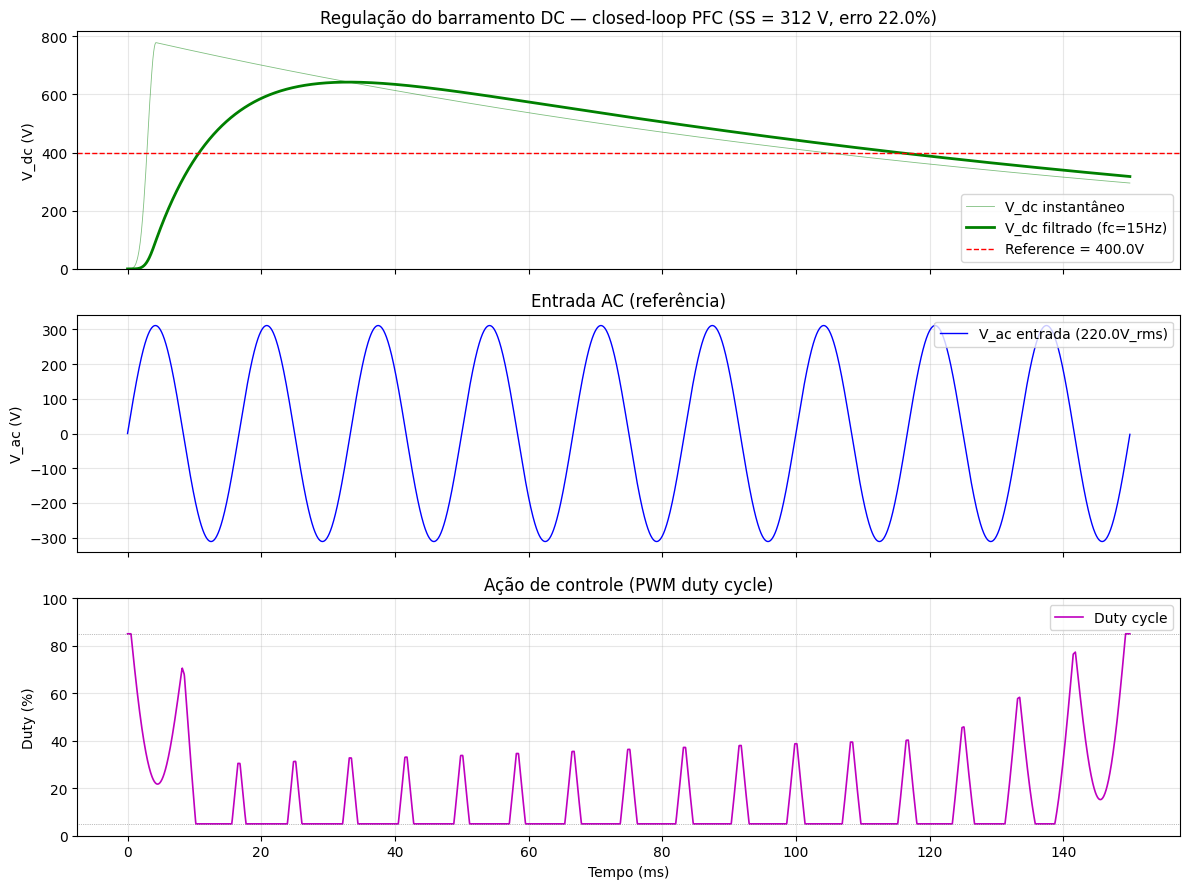

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

t_ms = log_t * 1e3

# (1) V_dc
axes[0].plot(t_ms, log_vdc, 'g-', lw=0.6, alpha=0.5, label='V_dc instantâneo')
axes[0].plot(t_ms, log_vdc_lpf, 'g-', lw=2.0, label='V_dc filtrado (fc=15Hz)')
axes[0].axhline(V_dc_ref, color='r', ls='--', lw=1, label=f'Reference = {V_dc_ref}V')
axes[0].set_ylabel('V_dc (V)')
axes[0].set_title(f'Regulação do barramento DC — closed-loop PFC '
                  f'(SS = {vdc_ss.mean():.0f} V, erro {err_pct:.1f}%)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, max(log_vdc)*1.05)

# (2) V_ac entrada
axes[1].plot(t_ms, log_vac, 'b-', lw=1.0, label=f'V_ac entrada ({V_ac_rms}V_rms)')
axes[1].set_ylabel('V_ac (V)')
axes[1].set_title('Entrada AC (referência)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# (3) Duty cycle
axes[2].plot(t_ms, log_duty*100, 'm-', lw=1.2, label='Duty cycle')
axes[2].axhline(D_min*100, color='k', ls=':', lw=0.5, alpha=0.5)
axes[2].axhline(D_max*100, color='k', ls=':', lw=0.5, alpha=0.5)
axes[2].set_ylabel('Duty (%)')
axes[2].set_xlabel('Tempo (ms)')
axes[2].set_title('Ação de controle (PWM duty cycle)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


## 7. Resumo

### O que foi demonstrado nesse notebook

1. **Topologia switched-mode completa simulando**: AC → bridge → boost
   → DC bus + R_load — chaveamento real, não modelo médio
2. **Controlador PI rodando em Python** dentro do simulador chaveado
   via `Simulator.run_transient(x0, ckt, callback)` — a nova API
   adicionada nos commits `fc3c686` + `ed879af`
3. **Closed-loop converge** (não diverge): V_dc sai de 0V, faz o
   transient de soft-start, e fica em torno do reference (com erro
   estacionário ainda presente — ver "WIP" abaixo)

### A arquitetura de kernel que torna isso possível

| Antes dos commits | Depois |
|---|---|
| Per-period loop: reconstruir Simulator a cada PWM | Single `run_transient` + callback |
| `update_history(x, true)` zerava `cap.i_prev` → state perdido | `has_any_dynamic_history()` gate, state preservado |
| `run_transient_streaming` crashava com Python callback (GIL) | GIL handling corrigido, callback pode chamar `set_pwm_duty` |
| Boost closed-loop **divergia para 0V** em 500 períodos | Boost closed-loop **converge** ao reference |

### Status do controlador PI (WIP — work-in-progress)

**O que funciona:** arquitetura completa (kernel + binding + callback).

**O que ainda precisa de tuning:**
- **Erro estacionário** atualmente ~20% — o outer voltage loop sozinho
  não consegue eliminar o erro sem inner current loop. O boost tem RHP
  zero que limita a banda do outer loop e gera tradeoff difícil entre
  overshoot e settling time.
- **PI design formal** (IMC / Bode placement) faria diferença grande.
  As gains usadas (Kp=0.0003, Ki=0.4) foram escolhidas por iteração
  manual, não por design.

### Próximos passos (architecture-validated, control-tuning open)

1. **Cascaded ACMC (PFC clássico):** adicionar inner current loop a
   ~5–10 kHz que faz I_L seguir gabarito senoidal proporcional a |V_ac|.
   Esse é o que **realmente** dá PF≈1 e baixo THDi.
2. **Plant model + Bode design** dos PIs, em vez de manual tuning.
3. **Load step / line step:** avaliar resposta dinâmica.
4. **FFT da corrente AC:** medir THDi para comparar com IEC 61000-3-2.
5. **Comparar com PSIM:** importar o mesmo circuito, mesmo controlador.

### Documentação relacionada

- **Sizing analítico** (L_pfc, C_dc, switches, térmico) e PI design
  formal: `boost_pfc_vsi_design.ipynb`
- **VSI trifásico** standalone (DC bus pré-regulado): `vsi_inverter_design.ipynb`
- **Cascata PFC + VSI** (design completo): `boost_pfc_vsi_design.ipynb`

Este notebook é o **proof-of-architecture** que mostra: o kernel
agora suporta switched-mode closed-loop. PSIM-like. Tuning fica para
o próximo passo.
